# Credit Risk Prediction – Model Interpretation

## 1. Objective

This notebook focuses on interpreting the XGBoost credit risk model
developed in the previous stage.

SHAP (SHapley Additive exPlanations) is used to:

- Identify the most influential features.
- Understand how individual features affect default predictions.
- Explore the relationship between feature values and predicted risk.
- Translate model outputs into potential business insights.

The analysis is performed on the validation set used during model
evaluation, ensuring consistency with the previous modeling stage.

## 2. Import Libraries

The following libraries are used for data manipulation, visualization,
model loading, and SHAP-based model interpretation.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap

from sklearn.model_selection import train_test_split

## 3. Load the Trained Model

The XGBoost model and preprocessing pipeline developed in Notebook 2
are loaded from the `models/` directory.

Using the same preprocessing pipeline is essential because the model
was trained on the transformed feature space generated by this pipeline.

In [34]:
# Load the trained XGBoost model and the fitted preprocessing pipeline.

xgb_model = joblib.load("../models/xgboost_model.joblib")
preprocessor = joblib.load("../models/preprocessor.joblib")

print("Model and preprocessor loaded successfully.")

Model and preprocessor loaded successfully.


### 4. Reproducibility Check

The model interpretation environment uses fixed package versions
compatible with the trained model and the SHAP analysis.

In [35]:
import numpy
import sklearn
import xgboost

print("NumPy:", numpy.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)
print("SHAP:", shap.__version__)

NumPy: 1.26.4
Pandas: 2.1.4
Scikit-learn: 1.3.0
XGBoost: 2.1.3
SHAP: 0.44.1


## 5. Load and Prepare the Validation Data

The original Home Credit dataset is loaded again to reconstruct the
same training and validation split used during model development.

The same `random_state`, `test_size`, and stratification strategy are
used to ensure that the validation observations are identical to those
used in Notebook 2.

In [36]:
# Load the original Home Credit training dataset.

df = pd.read_csv("application_train.csv")

# Separate predictors and target.
X = df.drop(columns=["TARGET"])
y = df["TARGET"]

print("Dataset shape:", df.shape)
print("Feature matrix:", X.shape)
print("Target:", y.shape)

Dataset shape: (307511, 122)
Feature matrix: (307511, 121)
Target: (307511,)


## 6. Recreate validation split

In [37]:
# Recreate the same train/validation split used in Notebook 2.

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Validation set:", X_valid.shape)

Training set: (246008, 121)
Validation set: (61503, 121)


## 7. Apply the Preprocessing Pipeline

The fitted preprocessing pipeline from Notebook 2 is applied to the
validation data.

No new preprocessing steps are fitted here. This ensures that the data
used for SHAP interpretation is transformed in exactly the same way as
the data used to train the XGBoost model.

In [38]:
# Transform the validation data using the fitted preprocessing pipeline.

X_valid_processed = preprocessor.transform(X_valid)

print("Processed validation shape:", X_valid_processed.shape)

Processed validation shape: (61503, 245)


## 8. SHAP Analysis

SHAP values can be computationally expensive to calculate for a large
dataset.

For this analysis, a representative sample of 5,000 validation
observations is used. This provides enough observations to identify
the main patterns while keeping the notebook computationally efficient.

In [39]:
# Use a representative validation sample for SHAP analysis.

X_shap = X_valid_processed[:5000]

print("SHAP sample shape:", X_shap.shape)

SHAP sample shape: (5000, 245)


## 9. SHAP TreeExplainer

Because the predictive model is based on XGBoost decision trees,
`TreeExplainer` is used to calculate SHAP values efficiently.

For each observation, SHAP values quantify how individual features
contribute to the model's prediction.

In general:

- Positive SHAP values push the prediction toward higher default risk.
- Negative SHAP values push the prediction toward lower default risk.
- Larger absolute SHAP values indicate stronger contributions.

In [40]:
# Create a SHAP explainer specifically designed for tree-based models.

explainer = shap.TreeExplainer(xgb_model)

print("SHAP TreeExplainer created successfully.")

SHAP TreeExplainer created successfully.


## 10. SHAP Value Calculation

SHAP values quantify the contribution of each feature to an individual
prediction.

For this analysis, SHAP values are calculated for a representative
sample of 5,000 observations from the validation set.

In [41]:
# Calculate SHAP values for the selected validation sample.

shap_values = explainer.shap_values(X_shap)

print("SHAP values calculated successfully.")
print("SHAP values shape:", shap_values.shape)

SHAP values calculated successfully.
SHAP values shape: (5000, 245)


## 11. Processed Feature Names

The preprocessing pipeline transforms the original variables through
imputation, scaling, and one-hot encoding.

The following step retrieves the names of the resulting features so
that SHAP results can be interpreted correctly.

In [42]:
# Retrieve feature names generated by the preprocessing pipeline.

feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))
print("First 10 features:")
print(feature_names[:10])

Number of processed features: 245
First 10 features:
['num__SK_ID_CURR' 'num__CNT_CHILDREN' 'num__AMT_INCOME_TOTAL'
 'num__AMT_CREDIT' 'num__AMT_ANNUITY' 'num__AMT_GOODS_PRICE'
 'num__REGION_POPULATION_RELATIVE' 'num__DAYS_BIRTH' 'num__DAYS_EMPLOYED'
 'num__DAYS_REGISTRATION']


## 12. Global feature importance

The SHAP values are converted into a DataFrame using the processed
feature names. This allows us to rank variables according to their
average contribution to the model predictions.

In [43]:
# Convert SHAP values into a DataFrame for easier analysis.

shap_df = pd.DataFrame(
    shap_values,
    columns=feature_names
)

print("SHAP DataFrame shape:", shap_df.shape)

SHAP DataFrame shape: (5000, 245)


In [44]:
# Calculate mean absolute SHAP value for each feature.

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean |SHAP|": np.abs(shap_values).mean(axis=0)
})

# Sort features by global importance.
feature_importance = feature_importance.sort_values(
    "Mean |SHAP|",
    ascending=False
)

feature_importance.head(15)

,Feature,Mean |SHAP|
30,num__EXT_SOURCE_3,0.375784
29,num__EXT_SOURCE_2,0.331306
5,num__AMT_GOODS_PRICE,0.235638
3,num__AMT_CREDIT,0.196618
28,num__EXT_SOURCE_1,0.151915
8,num__DAYS_EMPLOYED,0.104046
7,num__DAYS_BIRTH,0.098118
4,num__AMT_ANNUITY,0.096595
107,cat__CODE_GENDER_F,0.088477
10,num__DAYS_ID_PUBLISH,0.067948


## 13. Feature importance plot

The mean absolute SHAP value measures the average magnitude of each
feature's contribution to the model predictions.

Higher values indicate that a feature has a greater influence on the
model's output across the analyzed observations.

This measure does not indicate whether a feature increases or decreases
predicted risk. The direction of the effects is analyzed using the SHAP
beeswarm plot.

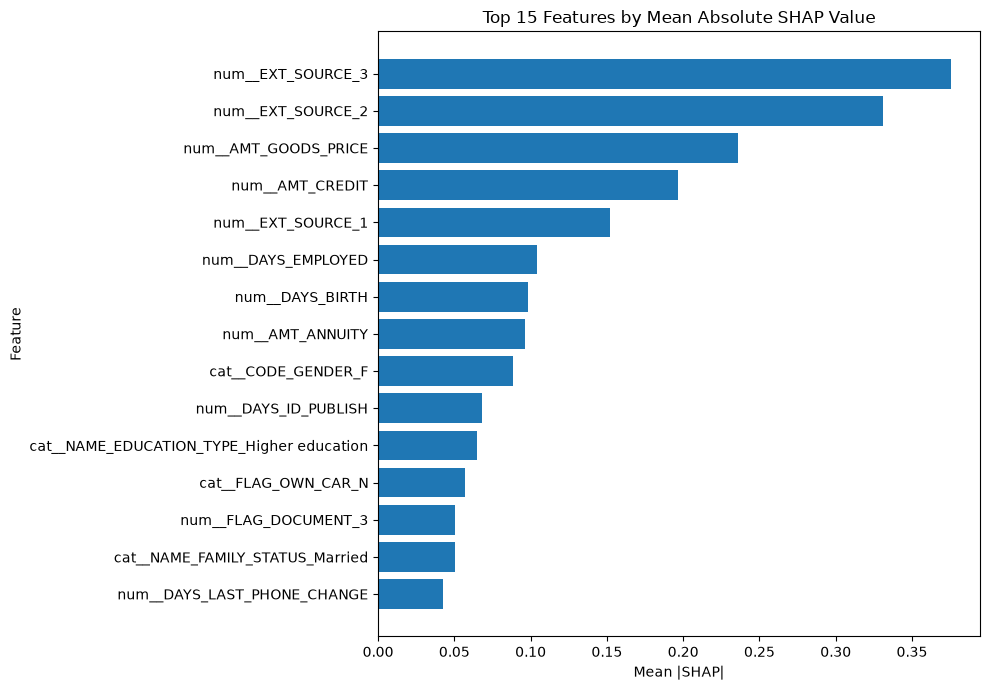

In [47]:
# Select the 15 most important features.
top_features = feature_importance.head(15).sort_values(
    "Mean |SHAP|",
    ascending=True
)

# Create the figure.
fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    top_features["Feature"],
    top_features["Mean |SHAP|"]
)

ax.set_xlabel("Mean |SHAP|")
ax.set_ylabel("Feature")
ax.set_title("Top 15 Features by Mean Absolute SHAP Value")

plt.tight_layout()

# Save the figure.
figures_dir = Path("../figures")
figures_dir.mkdir(parents=True, exist_ok=True)

fig.savefig(
    figures_dir / "shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 14. SHAP Beeswarm Plot

The SHAP beeswarm plot shows both the importance and direction of
feature effects.

Each point represents an observation. The horizontal position
corresponds to the SHAP value, while the color represents the original
feature value.

Positive SHAP values indicate a contribution toward a higher predicted
probability of default, while negative SHAP values indicate a
contribution toward a lower predicted probability of default.

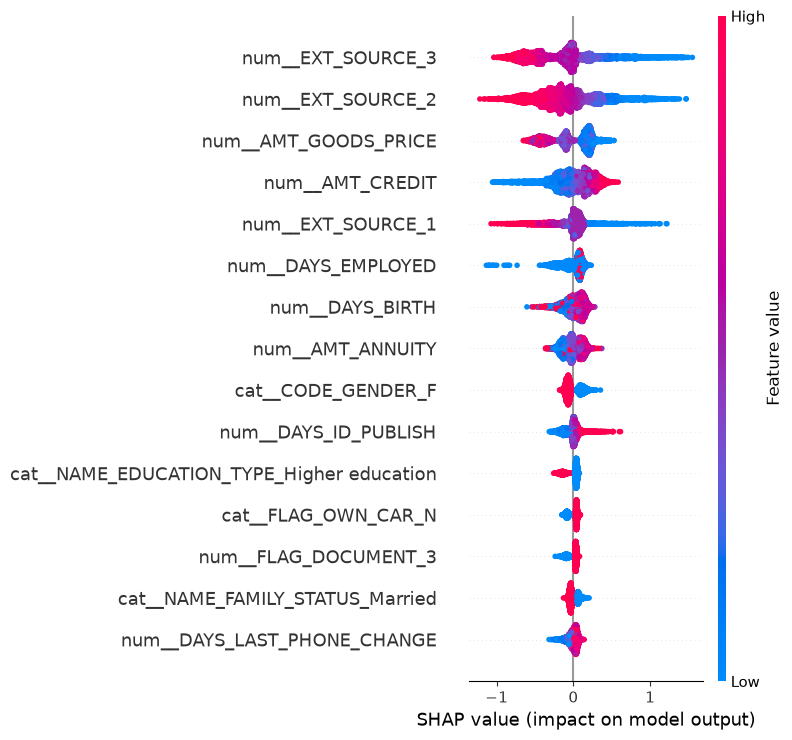

In [48]:
# Create the SHAP beeswarm plot.

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    max_display=15,
    show=False
)

plt.tight_layout()

# Save the figure.
plt.savefig(
    figures_dir / "shap_beeswarm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 15. Main Finding

The SHAP analysis shows that external credit indicators (EXT_SOURCE_1, EXT_SOURCE_2, and EXT_SOURCE_3) are among the most influential features in the XGBoost model. Higher values of these indicators generally contribute to lower predicted default risk, while lower values contribute to higher risk. Financial variables such as AMT_CREDIT, AMT_GOODS_PRICE, and AMT_ANNUITY also have substantial influence on model predictions. The direction and magnitude of these effects vary across features, highlighting the importance of interpreting model predictions beyond global feature importance.

## 16.  Analysis of the Most Influential Features

The global SHAP analysis identified five features with the largest
average contribution to the model predictions.

This section examines their contribution in greater detail, focusing on
the direction and magnitude of their effects.

### SHAP Dependence Plots

SHAP dependence plots show how the value of an individual feature is
related to its contribution to the model output.

The horizontal axis represents the feature value, while the vertical
axis represents its SHAP value. Positive SHAP values indicate a
contribution toward higher predicted default risk.

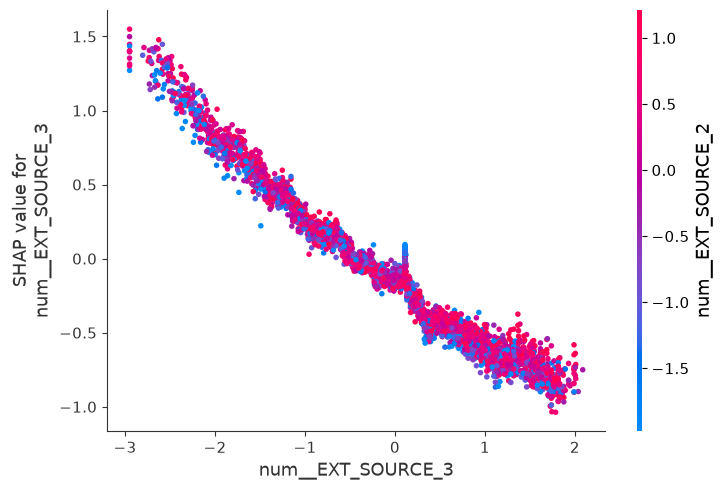

In [50]:
# Create and save the SHAP dependence plot for EXT_SOURCE_3.

shap.dependence_plot(
    "num__EXT_SOURCE_3",
    shap_values,
    X_shap,
    feature_names=feature_names,
    show=False
)

plt.tight_layout()

plt.savefig(
    figures_dir / "shap_dependence_EXT_SOURCE_3.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Higher values of EXT_SOURCE_3 consistently contribute to lower predicted default risk, while lower values contribute to higher predicted default risk. The relationship is strong and approximately monotonic across the analyzed range.

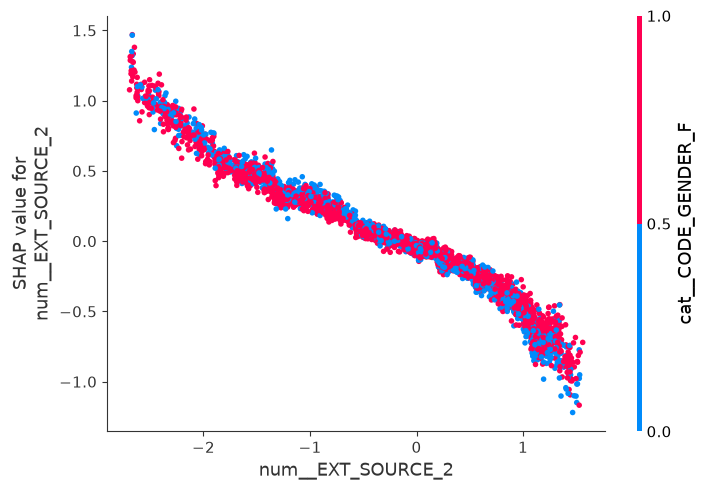

In [52]:
# Create and save the SHAP dependence plot for EXT_SOURCE_2.

shap.dependence_plot(
    "num__EXT_SOURCE_2",
    shap_values,
    X_shap,
    feature_names=feature_names,
    show=False
)

plt.tight_layout()

plt.savefig(
    figures_dir / "shap_dependence_EXT_SOURCE_2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Higher values of EXT_SOURCE_2 generally contribute to lower predicted default risk, while lower values contribute to higher predicted default risk.

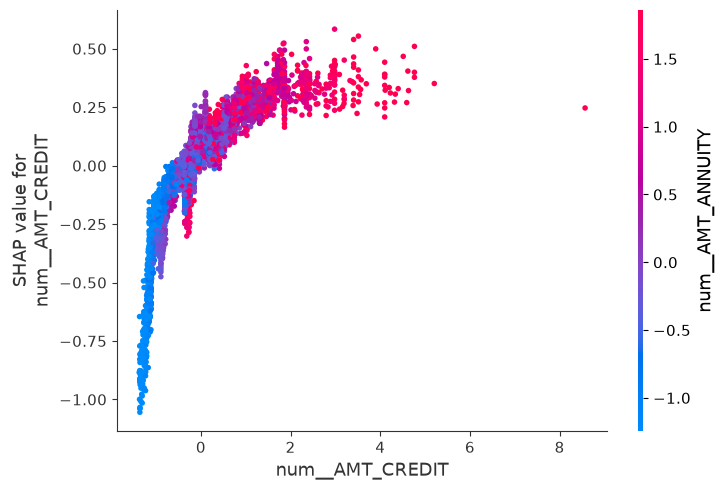

In [54]:
# Create and save the SHAP dependence plot for AMT_CREDIT.

shap.dependence_plot(
    "num__AMT_CREDIT",
    shap_values,
    X_shap,
    feature_names=feature_names,
    show=False
)

plt.tight_layout()

plt.savefig(
    figures_dir / "shap_dependence_AMT_CREDIT.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Higher values of AMT_CREDIT generally contribute to higher predicted default risk. The relationship is nonlinear: the contribution increases rapidly at lower-to-intermediate credit amounts and then tends to plateau at higher values.

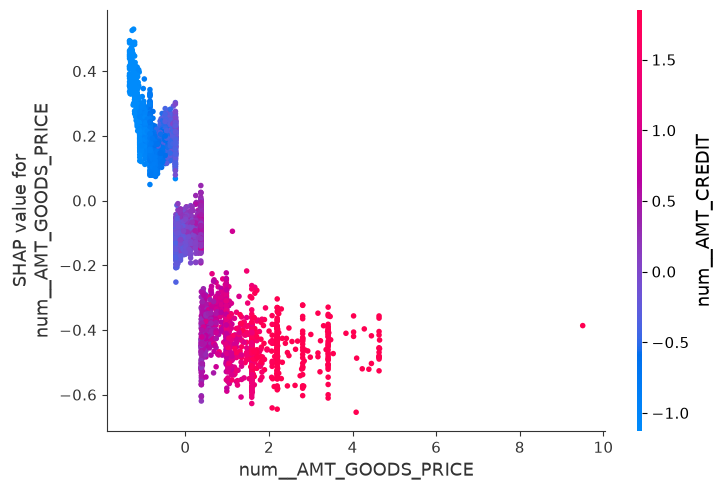

In [56]:
# Create and save the SHAP dependence plot for AMT_GOODS_PRICE.

shap.dependence_plot(
    "num__AMT_GOODS_PRICE",
    shap_values,
    X_shap,
    feature_names=feature_names,
    show=False
)

plt.tight_layout()

plt.savefig(
    figures_dir / "shap_dependence_AMT_GOODS_PRICE.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The SHAP dependence plot for `AMT_GOODS_PRICE` reveals a nonlinear
relationship with the model output.

Lower standardized values tend to contribute positively to the predicted
default risk, while higher values generally contribute negatively after
a transition region around the center of the distribution.

The feature is also strongly related to `AMT_CREDIT`, which is shown by
the color scale. This suggests that the model may be capturing complex
relationships among financial variables rather than relying on a simple
linear effect.

These results represent model associations and should not be interpreted
as causal relationships.

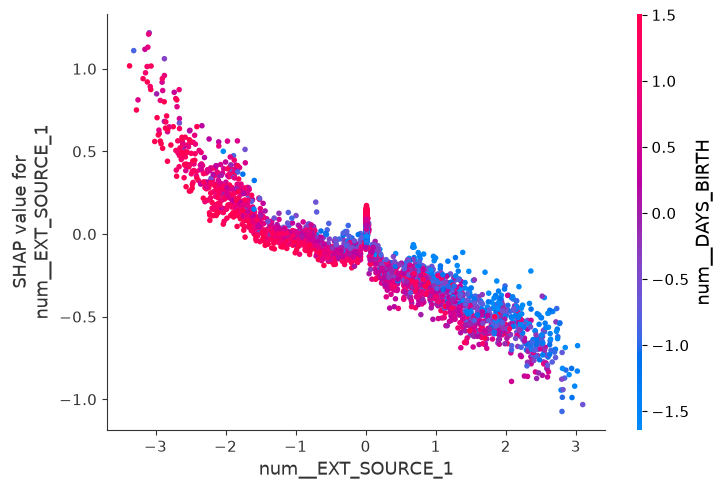

In [58]:
# Create and save the SHAP dependence plot for EXT_SOURCE_1.

shap.dependence_plot(
    "num__EXT_SOURCE_1",
    shap_values,
    X_shap,
    feature_names=feature_names,
    show=False
)

plt.tight_layout()

plt.savefig(
    figures_dir / "shap_dependence_EXT_SOURCE_1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Higher values of EXT_SOURCE_1 generally contribute to lower predicted default risk, while lower values contribute to higher predicted default risk.

## Interpretation of the Main Features

The SHAP analysis identifies the three external credit indicators
(`EXT_SOURCE_1`, `EXT_SOURCE_2`, and `EXT_SOURCE_3`) as particularly
important features in the XGBoost model.

All three exhibit a strong negative relationship between their
standardized values and SHAP values: higher scores generally contribute
to lower predicted default risk, whereas lower scores contribute to
higher predicted risk.

Financial variables also play an important role. `AMT_CREDIT` shows a
nonlinear positive relationship with the model output, with higher
credit amounts generally contributing to higher predicted risk. In
contrast, `AMT_GOODS_PRICE` exhibits a more complex nonlinear pattern.

These results describe associations learned by the predictive model and
should not be interpreted as causal effects.

## 17. Individual Prediction Explanation

Global SHAP analysis describes the overall behavior of the model.

To demonstrate local interpretability, this section explains the
prediction for an individual validation observation.

The SHAP contributions show which features pushed the prediction toward
higher or lower default risk for that specific application.

In [59]:
# Select one observation from the SHAP sample.

observation_index = 0

X_individual = X_shap[observation_index]

print("Observation index:", observation_index)
print("Actual target:", y_valid.iloc[observation_index])

Observation index: 0
Actual target: 0


### Individual Model Prediction

The selected validation observation is evaluated using the trained
XGBoost model.

The predicted probability represents the model's estimated probability
of default for this individual application.

In [60]:
# Obtain the model prediction for the selected observation.

individual_probability = xgb_model.predict_proba(
    X_individual.reshape(1, -1)
)[0, 1]

individual_prediction = int(individual_probability >= 0.5)

print(f"Predicted probability of default: {individual_probability:.4f}")
print(f"Predicted class at threshold 0.50: {individual_prediction}")
print(f"Actual target: {y_valid.iloc[observation_index]}")

Predicted probability of default: 0.0456
Predicted class at threshold 0.50: 0
Actual target: 0


## 18. Local SHAP Explanation

The global SHAP analysis describes the overall behavior of the model,
while local SHAP values explain an individual prediction.

For the selected application, positive SHAP values push the prediction
toward higher default risk, while negative SHAP values push it toward
lower default risk.

In [61]:
# Extract SHAP values for the selected observation.

individual_shap = shap_values[observation_index]

print("Number of SHAP values:", len(individual_shap))

Number of SHAP values: 245


In [62]:
# Features pushing the prediction toward higher default risk.

positive_contributions = pd.DataFrame({
    "Feature": feature_names,
    "SHAP value": individual_shap
})

positive_contributions = positive_contributions[
    positive_contributions["SHAP value"] > 0
].sort_values(
    "SHAP value",
    ascending=False
)

positive_contributions.head(10)

,Feature,SHAP value
8,num__DAYS_EMPLOYED,0.154989
7,num__DAYS_BIRTH,0.148409
4,num__AMT_ANNUITY,0.098252
107,cat__CODE_GENDER_F,0.087679
3,num__AMT_CREDIT,0.085447
30,num__EXT_SOURCE_3,0.067415
28,num__EXT_SOURCE_1,0.067271
11,num__OWN_CAR_AGE,0.065896
108,cat__CODE_GENDER_M,0.049240
226,cat__ORGANIZATION_TYPE_Transport: type 4,0.033889


In [63]:
# Features pushing the prediction toward lower default risk.

negative_contributions = pd.DataFrame({
    "Feature": feature_names,
    "SHAP value": individual_shap
})

negative_contributions = negative_contributions[
    negative_contributions["SHAP value"] < 0
].sort_values(
    "SHAP value",
    ascending=True
)

negative_contributions.head(10)

,Feature,SHAP value
5,num__AMT_GOODS_PRICE,-0.467503
29,num__EXT_SOURCE_2,-0.215295
130,cat__NAME_EDUCATION_TYPE_Higher education,-0.184808
103,num__AMT_REQ_CREDIT_BUREAU_QRT,-0.112719
133,cat__NAME_EDUCATION_TYPE_Secondary / secondary...,-0.084746
110,cat__FLAG_OWN_CAR_N,-0.083559
80,num__FLAG_DOCUMENT_3,-0.067847
10,num__DAYS_ID_PUBLISH,-0.062049
6,num__REGION_POPULATION_RELATIVE,-0.036708
21,num__HOUR_APPR_PROCESS_START,-0.033311


## 19. SHAP Additivity Check

SHAP values decompose the model output into a base value plus the
contribution of each feature.

For the XGBoost model, the explanation is expressed on the model's
log-odds scale. Applying the logistic function converts the reconstructed
model output into the predicted probability of default.

In [64]:
# Retrieve the expected model output (base value).
base_value = explainer.expected_value

# SHAP values for the selected observation.
individual_shap = shap_values[observation_index]

# Reconstruct the model's raw output.
raw_output = base_value + individual_shap.sum()

# Convert raw output (log-odds) to probability.
reconstructed_probability = 1 / (1 + np.exp(-raw_output))

print("Base value:", base_value)
print("Sum of SHAP values:", individual_shap.sum())
print("Reconstructed raw output:", raw_output)
print(f"Reconstructed probability: {reconstructed_probability:.4f}")
print(f"Model probability: {individual_probability:.4f}")

Base value: -2.458694
Sum of SHAP values: -0.58155644
Reconstructed raw output: -3.0402503
Reconstructed probability: 0.0456
Model probability: 0.0456


## 20. SHAP Waterfall Plot

The waterfall plot provides a local explanation of the selected
prediction.

It shows how individual feature contributions move the model output
away from its baseline prediction.

Positive SHAP values push the model output toward higher predicted risk,
while negative SHAP values push it toward lower predicted risk.

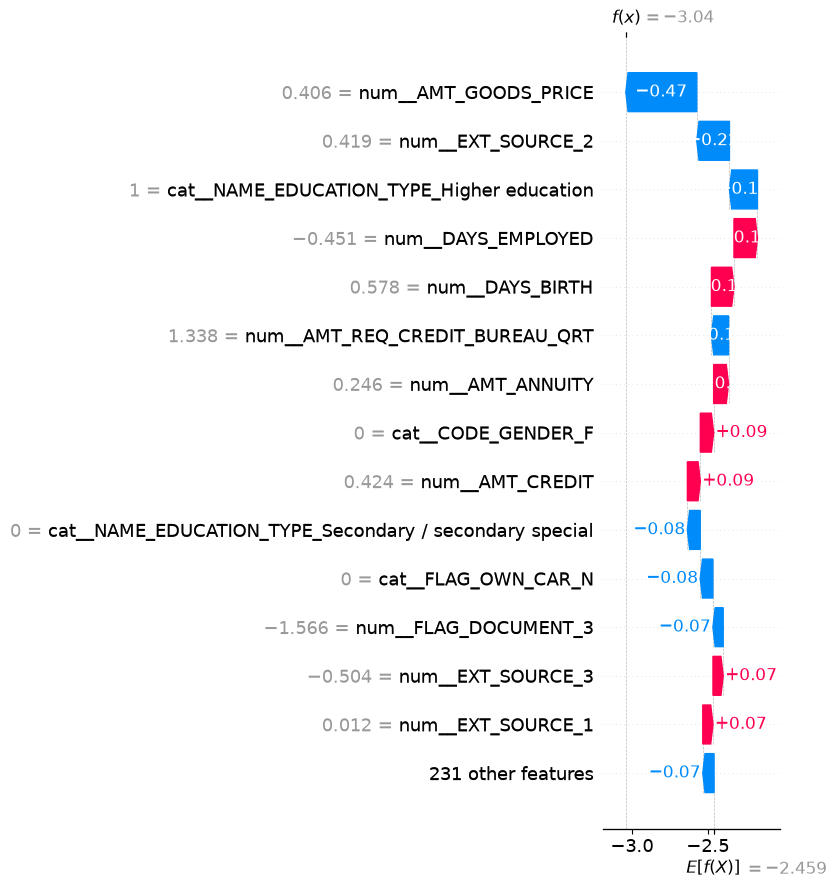

In [65]:
# Create a SHAP Explanation object for the selected observation.

individual_explanation = shap.Explanation(
    values=individual_shap,
    base_values=base_value,
    data=X_individual,
    feature_names=feature_names
)

# Generate the waterfall plot.
shap.plots.waterfall(
    individual_explanation,
    max_display=15,
    show=False
)

plt.tight_layout()

plt.savefig(
    figures_dir / "shap_waterfall_individual.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The model correctly classified the application as non-default at the 0.50 classification threshold.

### Interpretation of the Individual Prediction

The selected application has an actual target value of 0 and a predicted
default probability of 4.56% at the individual prediction level.

The SHAP waterfall plot shows that the model's baseline output is
adjusted by multiple feature contributions. `AMT_GOODS_PRICE` and
`EXT_SOURCE_2` provide the largest contributions toward a lower predicted
risk, while `DAYS_EMPLOYED`, `DAYS_BIRTH`, and `AMT_ANNUITY` contribute
toward higher predicted risk.

The final balance of these contributions results in a model output of
-3.04 on the log-odds scale, corresponding to a predicted default
probability of 4.56%.

This explanation describes the model's learned associations and should
not be interpreted as a causal assessment of the applicant.

# 21. Business Interpretation

The SHAP analysis provides an interpretable view of how the XGBoost
model evaluates credit risk.

At the global level, external credit indicators (`EXT_SOURCE_1`,
`EXT_SOURCE_2`, and `EXT_SOURCE_3`) are among the most influential
features. Higher values of these indicators generally contribute to
lower predicted default risk, while lower values contribute to higher
predicted risk.

Financial variables such as `AMT_CREDIT`, `AMT_GOODS_PRICE`, and
`AMT_ANNUITY` also have a substantial influence on model predictions.
Their effects are nonlinear, highlighting the ability of XGBoost to
capture relationships that would be difficult to represent with a
strictly linear model.

From a business perspective, the model could be used as a risk-ranking
tool to help prioritize applications for additional review. The
predicted probability should not be interpreted as a definitive
decision by itself. Classification thresholds should instead be selected
according to the relative costs of false positives and false negatives.

The local SHAP analysis demonstrates how individual applications can be
explained. For the selected validation observation, the model estimated
a 4.56% probability of default. `AMT_GOODS_PRICE` and `EXT_SOURCE_2`
were among the strongest contributions toward lower predicted risk,
while `DAYS_EMPLOYED`, `DAYS_BIRTH`, and `AMT_ANNUITY` contributed toward
higher predicted risk.

The analysis also highlights the importance of model governance.
Features such as gender appear among the influential variables and
therefore warrant additional fairness and regulatory analysis before
using the model in a real credit decision-making process.

Overall, SHAP improves the transparency of the predictive model by
showing both global feature importance and individual prediction
contributions.

# 22. Conclusions

This notebook used SHAP to interpret the XGBoost credit risk model
developed in the previous modeling stage.

The main findings are:

1. External credit indicators (`EXT_SOURCE_1`, `EXT_SOURCE_2`, and
   `EXT_SOURCE_3`) are among the most influential features in the model.
   Higher values generally contribute to lower predicted default risk.

2. Financial variables, particularly `AMT_CREDIT` and
   `AMT_GOODS_PRICE`, also have a substantial influence on predictions.
   Their relationships with model output are nonlinear.

3. The SHAP beeswarm plot provides both global importance and the
   direction of feature contributions, while dependence plots reveal
   more detailed relationships between individual features and model
   output.

4. Local SHAP explanations show how different features combine to
   produce an individual prediction. For the selected validation
   observation, the model predicted a 4.56% probability of default,
   consistent with its observed target of 0.

5. The SHAP additivity check successfully reconstructed the model output,
   confirming the consistency between the individual explanation and
   the original model prediction.

6. The analysis demonstrates that model interpretability is essential
   when applying machine learning to credit risk, particularly when
   features related to sensitive or potentially regulated attributes
   are involved.

The combination of predictive performance and model interpretability
provides a stronger framework for evaluating the usefulness of the
credit risk model.

# 23. Limitations and Next Steps

## Limitations

- The analysis uses a validation sample from the Home Credit dataset and
  does not represent a deployment environment.

- The XGBoost model was evaluated using a single train-validation split.
  Cross-validation could provide a more robust estimate of generalization
  performance.

- The classification threshold was explored using a limited set of
  candidate values. A production threshold should be selected according
  to explicit business costs and operational requirements.

- SHAP explanations describe associations learned by the model and should
  not be interpreted as causal effects.

- Features related to demographic characteristics require additional
  fairness and regulatory analysis before being considered for real-world
  credit decisions.

## Next Steps

Potential improvements include:

- Hyperparameter optimization.
- Cross-validation.
- Probability calibration.
- Cost-sensitive threshold optimization.
- Fairness analysis across relevant groups.
- Additional feature engineering.
- Model monitoring and drift detection.
- Evaluation on an independent test or out-of-time dataset.

# 24. Project Summary

| Component | Result |
|---|---|
| Dataset | Home Credit Application Train |
| Observations | 307,511 |
| Original features | 121 |
| Processed features | 245 |
| Baseline model | Logistic Regression |
| Main model | XGBoost |
| XGBoost ROC-AUC | 0.762 |
| XGBoost PR-AUC | 0.256 |
| SHAP sample | 5,000 observations |
| Most influential feature | EXT_SOURCE_3 |
| Individual example | 4.56% predicted default probability |